In [1]:
from datasets import PASTIS
TOP_DIR = "/home/user/data_shared"
labels_path =  "masks/PASTIS_test"
metadata_path = "/home/user/data_shared/masks/PASTIS/metadata.geojson"
val_folds = [4]
# models = "/home/user/results_shared/fourier_learned_2tile_alltimes_france_largermodel_nocloud/2026-02-12_10-12-55"



val_ds_T31TFM = PASTIS(
    top_dir=TOP_DIR,
    s2_tile="T31TFM",
    labels_path=labels_path,
    metadata_path=metadata_path,
    train_val_key="val",
    val_folds=val_folds,
)

val_ds_T32ULU = PASTIS(
    top_dir=TOP_DIR,
    s2_tile="T32ULU",
    labels_path=labels_path,
    metadata_path=metadata_path,
    train_val_key="val",
    val_folds=val_folds,
)

Building val image label pairs: 100%|██████████| 19/19 [00:00<00:00, 43.13it/s]


In [2]:
from models.LIANet import LIANetLight
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# This should be loaded with n_blocks:

# Fill values from used_parameters.json
pretraining_T31TFM = LIANetLight(
    timestamp_dim=43,
    time_mode="fourier_learned",
    num_time_frequencies=8,
    time_input_dim=3,
    time_mlp_hidden=64,
    levels=13,
    n_min=16,
    growth=2,
    table_size=524288,
    feat_dim=128,
    complete_tile_size=10980,
    out_channels=12,  # or 12 if you want to match pretraining
    preproj_channels=128,
    resunet_backbone_size="small",
    bilinear=True,
    hash_vectorized=True,
    final_activation=None,
    n_blocks = 3

).to(device)

# Load checkpoint (update path as needed)
lianet_light_ckpt = torch.load("/home/user/results_shared/fourier_learned_2tile_alltimes_france_largermodel_nocloud/2026-02-19_15-31-25/model_checkpoints/checkpoint_Epoch400_Iteration800000.pt", map_location=device)
pretraining_T31TFM.load_state_dict(lianet_light_ckpt["model_state_dict"], strict=False)
pretraining_T31TFM.eval()
print("done")


/opt/conda/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/opt/conda/lib/python3.10/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


done


In [3]:
# Fill values from used_parameters.json
pretraining_T32ULU = LIANetLight(
    timestamp_dim=43,
    time_mode="fourier_learned",
    num_time_frequencies=8,
    time_input_dim=3,
    time_mlp_hidden=64,
    levels=13,
    n_min=16,
    growth=2,
    table_size=524288,
    feat_dim=128,
    complete_tile_size=10980,
    out_channels=12,  # or 12 if you want to match pretraining
    preproj_channels=128,
    resunet_backbone_size="small",
    bilinear=True,
    hash_vectorized=True,
    final_activation=None,
    n_blocks = 3
).to(device)

# Load checkpoint (update path as needed)
lianet_light_ckpt = torch.load("/home/user/results_shared/fourier_learned_2tile_alltimes_france_largermodel_nocloud/2026-02-12_10-12-55_T32ULU/model_checkpoints/checkpoint_Epoch801_Iteration1600000.pt", map_location=device)
pretraining_T32ULU.load_state_dict(lianet_light_ckpt["model_state_dict"], strict=False)
pretraining_T32ULU.eval()
print("done")


done


In [4]:
import torch
from collections import OrderedDict
from models.models_finetune import DownstreamModel

def _strip_module_prefix(state_dict):
    # handles DataParallel / DDP checkpoints that save keys like "module.xxx"
    if not any(k.startswith("module.") for k in state_dict.keys()):
        return state_dict
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        new_sd[k[len("module."):]] = v
    return new_sd

def load_finetuned(model, ckpt_path, device="cuda", strict=True):
    ckpt = torch.load(ckpt_path, map_location="cpu")

    # your save format uses "model_state_dict"
    sd = ckpt.get("model_state_dict", ckpt)
    sd = _strip_module_prefix(sd)

    missing, unexpected = model.load_state_dict(sd, strict=strict)
    print(f"[load] missing keys: {len(missing)}")
    print(f"[load] unexpected keys: {len(unexpected)}")
    if len(missing) and len(missing) < 50:
        print("  missing (first):", missing[:10])
    if len(unexpected) and len(unexpected) < 50:
        print("  unexpected (first):", unexpected[:10])

    model.to(device)
    return ckpt


finetune_model_path_T32ULU = "/home/user/results_shared/fourier_learned_2tile_alltimes_france_largermodel_nocloud/2026-02-12_10-12-55_T32ULU"
finetune_checkpoint_rel_T32ULU = "model_checkpoints/checkpoint_Epoch801_Iteration1600000.pt"

num_classes = 20
activation = "none"

ft_model_t32ulu_pretraining = DownstreamModel(
    model_path=finetune_model_path_T32ULU,
    checkpoint_path_relative=finetune_checkpoint_rel_T32ULU,   # load pretrain first (optional)
    adaption_strategy="replace_final_block",
    num_classes=num_classes,
    activation=activation,
).to(device)

# NOW load finetuned checkpoint on top:
ckpt = load_finetuned(ft_model_t32ulu_pretraining, "/home/user/results_local/finetuning_results/replace_final_block__large_no_cloud_backbone/2026-02-17_10-05-05/model_checkpoints/last_checkpoint.pt", device=device, strict=True)

ft_model_t32ulu_pretraining.eval()



finetune_model_path_T31TFM = "/home/user/results_shared/fourier_learned_2tile_alltimes_france_largermodel_nocloud/2026-02-19_15-31-25"
finetune_checkpoint_rel_T31TFM = "model_checkpoints/checkpoint_Epoch400_Iteration800000.pt"


ft_model_t31TFM_pretraining = DownstreamModel(
    model_path=finetune_model_path_T31TFM,
    checkpoint_path_relative=finetune_checkpoint_rel_T31TFM,   # load pretrain first (optional)
    adaption_strategy="replace_final_block",
    num_classes=num_classes,
    activation=activation,
).to(device)

# NOW load finetuned checkpoint on top:
# ckpt = load_finetuned(ft_model_t31TFM_pretraining, "/home/user/results_local/finetuning_results/replace_final_block__large_no_cloud_backbone/2026-02-17_10-05-05/model_checkpoints/last_checkpoint.pt", device=device, strict=True)

# ft_model_t31TFM_pretraining.eval()

LIANetLight(
  (encoder): HashTableEncoder2D()
  (time_encoder): LearnedFourierTimeEncoder1D(
    (proj): Linear(in_features=16, out_features=1664, bias=True)
  )
  (preproj): Conv2d(1664, 128, kernel_size=(1, 1), stride=(1, 1))
  (light_head): LiteCNNHead(
    (stem): Sequential(
      (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): GroupNorm(16, 256, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
    )
    (blocks): Sequential(
      (0): ConvResBlock(
        (block): Sequential(
          (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): GroupNorm(16, 256, eps=1e-05, affine=True)
          (2): GELU(approximate='none')
          (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): GroupNorm(16, 256, eps=1e-05, affine=True)
        )
        (act): GELU(approximate='none')
      )
      (1): ConvResBlock(
        (block): Sequential(
         

In [7]:
# Replace all parameters of pretrain_model.generator (except .final_layer) with those from lianet_light

# for name, param in pretraining_T31TFM.named_parameters():
#     print(name)
#     if not name.startswith("final_layer"):  # skip final_layer
#         target_param = dict(model.generator.named_parameters()).get(name, None)
#         if target_param is not None:
#             target_param.data.copy_(param.data)

# Replace the final_layer entirely
# model.generator.encoder.tables = pretraining_T31TFM.encoder.tables
# model.generator.time_encoder.freqs = pretraining_T31TFM.time_encoder.freqs
# model.generator.time_encoder.proj.weight = pretraining_T31TFM.time_encoder.proj.weight
# model.generator.time_encoder.proj.bias = pretraining_T31TFM.time_encoder.proj.bias
# model.generator.preproj.weight = pretraining_T31TFM.preproj.weight
# model.generator.preproj.bias = pretraining_T31TFM.preproj.bias
# model.generator.light_head.stem[0].weight = pretraining_T31TFM.light_head.stem[0].weight
# model.generator.light_head.stem[1].weight = pretraining_T31TFM.light_head.stem[1].weight
# model.generator.light_head.stem[1].bias = pretraining_T31TFM.light_head.stem[1].bias
# model.generator.light_head.blocks[0].block[0].weight = pretraining_T31TFM.light_head.blocks[0].block[0].weight
# model.generator.light_head.blocks[0].block[1].weight = pretraining_T31TFM.light_head.blocks[0].block[1].weight
# model.generator.light_head.blocks[0].block[1].bias = pretraining_T31TFM.light_head.blocks[0].block[1].bias
# model.generator.light_head.blocks[0].block[3].weight = pretraining_T31TFM.light_head.blocks[0].block[3].weight
# model.generator.light_head.blocks[0].block[4].weight = pretraining_T31TFM.light_head.blocks[0].block[4].weight
# model.generator.light_head.blocks[0].block[4].bias = pretraining_T31TFM.light_head.blocks[0].block[4].bias
# model.generator.light_head.blocks[1].block[0].weight = pretraining_T31TFM.light_head.blocks[1].block[0].weight
# model.generator.light_head.blocks[1].block[1].weight = pretraining_T31TFM.light_head.blocks[1].block[1].weight
# model.generator.light_head.blocks[1].block[1].bias = pretraining_T31TFM.light_head.blocks[1].block[1].bias
# model.generator.light_head.blocks[1].block[3].weight = pretraining_T31TFM.light_head.blocks[1].block[3].weight
# model.generator.light_head.blocks[1].block[4].weight = pretraining_T31TFM.light_head.blocks[1].block[4].weight
# model.generator.light_head.blocks[1].block[4].bias = pretraining_T31TFM.light_head.blocks[1].block[4].bias
# model.generator.light_head.blocks[2].block[0].weight = pretraining_T31TFM.light_head.blocks[2].block[0].weight
# model.generator.light_head.blocks[2].block[1].weight = pretraining_T31TFM.light_head.blocks[2].block[1].weight
# model.generator.light_head.blocks[2].block[1].bias = pretraining_T31TFM.light_head.blocks[2].block[1].bias
# model.generator.light_head.blocks[2].block[3].weight = pretraining_T31TFM.light_head.blocks[2].block[3].weight
# model.generator.light_head.blocks[2].block[4].weight = pretraining_T31TFM.light_head.blocks[2].block[4].weight
# model.generator.light_head.blocks[2].block[4].bias = pretraining_T31TFM.light_head.blocks[2].block[4].bias
# model.generator.light_head.proj.weight = pretraining_T31TFM.light_head.proj.weight
# model.generator.light_head.proj.bias = pretraining_T31TFM.light_head.proj.bias
ft_model_t31TFM_pretraining.new_head = ft_model_t32ulu_pretraining.new_head
ft_model_t31TFM_pretraining.final_activation = ft_model_t32ulu_pretraining.final_activation
ft_model_t31TFM_pretraining.eval()
print("done")
# # model

done


/opt/conda/lib/python3.10/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


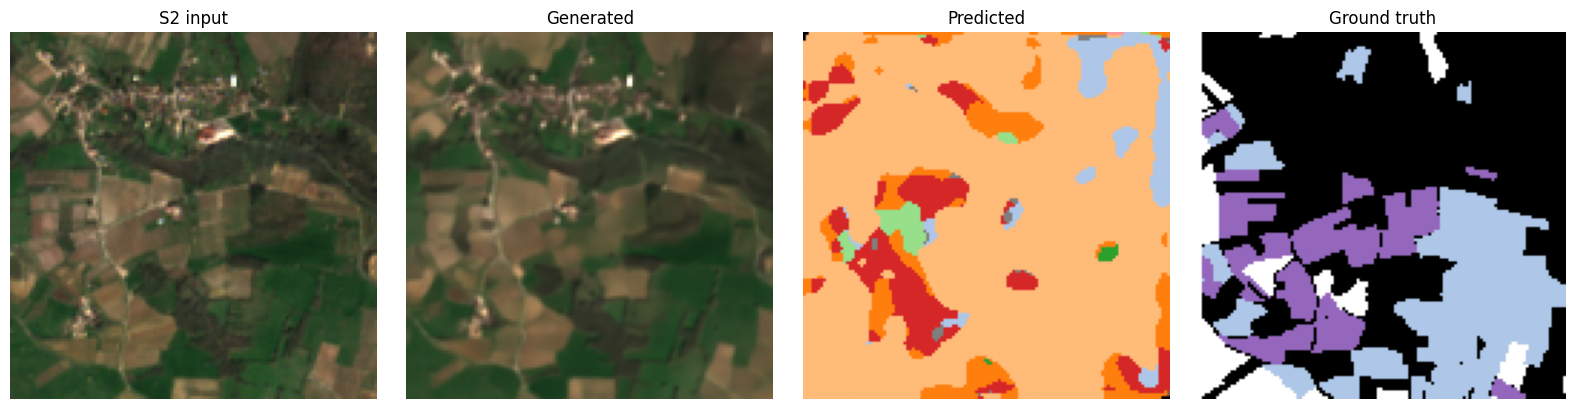

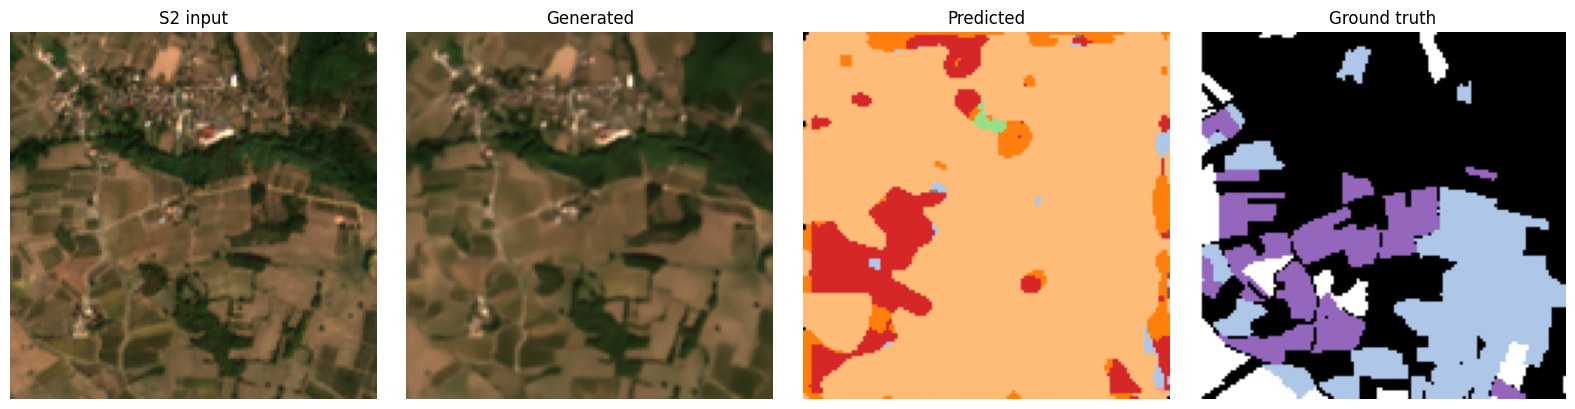

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from utils import s2_to_rgb

# PASTIS colormap (20 classes)
colors = [
    (0, 0, 0),
    (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
    (1.0, 0.4980392156862745, 0.054901960784313725),
    (1.0, 0.7333333333333333, 0.47058823529411764),
    (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
    (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    (1.0, 0.596078431372549, 0.5882352941176471),
    (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
    (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
    (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
    (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
    (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
    (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
    (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
    (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
    (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
    (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
    (1, 1, 1),
]

cmap = ListedColormap(colors)

num_samples = min(2, len(val_ds_T31TFM))  # just visualize 2 samples for brevity

with torch.no_grad():
    for idx in range(num_samples):
        sample = val_ds_T31TFM[idx]

        timestamp = sample["delta_days"].unsqueeze(0).to(device)
        x_s2 = torch.tensor(sample["x_s2"], dtype=torch.float32, device=device).unsqueeze(0)
        y_s2 = torch.tensor(sample["y_s2"], dtype=torch.float32, device=device).unsqueeze(0)
        s2 = torch.tensor(sample["s2data"], dtype=torch.float32, device=device).unsqueeze(0)
        label = torch.tensor(sample["label"], dtype=torch.long, device=device)

        reconstruction, outputs = ft_model_t31TFM_pretraining(timestamp, y_s2, x_s2)

        s2_np = s2.detach().cpu().numpy()[0].astype(np.float32)
        rec_np = reconstruction.detach().cpu().numpy()[0].astype(np.float32)
        outputs_np = outputs.detach().cpu().numpy()[0]
        label_np = label.detach().cpu().numpy()

        pred_argmax = np.argmax(outputs_np, axis=0).astype(np.uint8)
        label_to_plot = label_np.squeeze().astype(np.uint8)

        fig, axs = plt.subplots(1, 4, figsize=(16, 4))
        axs[0].imshow(s2_to_rgb(s2_np))
        axs[0].set_title("S2 input")
        axs[1].imshow(s2_to_rgb(rec_np))
        axs[1].set_title("Generated")
        axs[2].imshow(pred_argmax, cmap=cmap, vmin=0, vmax=19)
        axs[2].set_title("Predicted")
        axs[3].imshow(label_to_plot, cmap=cmap, vmin=0, vmax=19)
        axs[3].set_title("Ground truth")

        for ax in axs:
            ax.axis("off")
        plt.tight_layout()
        plt.show()
